# 🤖 TP4 — Machine Learning Aplicado
## Sistemas Inteligentes 2026

**Docentes:** Lic. Martín Vargas | Ing. Miguel Pérez Díaz  

---

### Instrucciones generales

- Completá **todas** las celdas de código marcadas con `# ✏️ TU CÓDIGO ACÁ`
- Respondé las **preguntas de reflexión** en las celdas de texto (hacé doble clic para editarlas)
- Comentá tu código: explicá brevemente **qué hace** cada bloque importante
- Al finalizar, guardá el notebook como `.ipynb` y subilo al aula virtual junto con el informe PDF

---

### 📦 Tu dataset asignado

Buscá en la tabla siguiente el dataset que corresponde a tu grupo y **copiá la URL** en la celda de carga (Sección 1).

| Grupo | Dataset | Problema | URL |
|-------|---------|----------|-----|
| **Grupo 1** | Heart Disease (UCI) | Clasificación: ¿tiene enfermedad cardíaca? | `sklearn.datasets` |
| **Grupo 2** | Diabetes | Clasificación: ¿tiene diabetes? | `sklearn.datasets` |
| **Grupo 3** | Iris (extendido) | Clasificación: especie de flor | `sklearn.datasets` |
| **Grupo 4** | California Housing | Regresión: precio de vivienda | `sklearn.datasets` |
| **Grupo 5** | Breast Cancer | Clasificación: ¿tumor maligno o benigno? | `sklearn.datasets` |
| **Grupo 6** | Wine Quality | Clasificación: calidad del vino | `sklearn.datasets` |
| **Grupo 7** | Penguins (Palmer) | Clasificación: especie de pingüino | `seaborn.load_dataset` |
| **Grupo 8** | Titanic | Clasificación: ¿sobrevivió el pasajero? | `seaborn.load_dataset` |

> ✅ Todos los datasets se cargan desde librerías preinstaladas en Colab. No se necesitan URLs externas.

---

**Integrantes del grupo:**
- Nombre 1:
- Nombre 2:
- Nombre 3 (si corresponde):

---
## Sección 0 — Importar librerías

Esta celda ya está completada. Solo ejecutala.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print('✅ Librerías importadas correctamente')

---
## Sección 1 — Carga del dataset

Reemplazá la URL con la de tu grupo. Si sos del **Grupo 5**, seguí las instrucciones del comentario.

In [2]:
import pandas as pd
import numpy as np
from sklearn import datasets
import seaborn as sns

# ─────────────────────────────────────────────
# GRUPO 1 — Heart Disease (UCI)
# ─────────────────────────────────────────────
# data = datasets.fetch_openml(name='heart-c', version=1, as_frame=True)
# df = data.frame
# df['target'] = (df['class'] == 'tested_positive').astype(int)
# df = df.drop(columns=['class'])

# ─────────────────────────────────────────────
# GRUPO 2 — Diabetes
# ─────────────────────────────────────────────
# data = datasets.load_diabetes()
# df = pd.DataFrame(data.data, columns=data.feature_names)
# df['target'] = (data.target > data.target.mean()).astype(int)

# ─────────────────────────────────────────────
# GRUPO 3 — Iris
# ─────────────────────────────────────────────
# data = datasets.load_iris()
# df = pd.DataFrame(data.data, columns=data.feature_names)
# df['target'] = data.target

# ─────────────────────────────────────────────
# GRUPO  — California Housing (regresión)
# ─────────────────────────────────────────────
data = datasets.fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # precio en cientos de miles de USD

# ─────────────────────────────────────────────
# GRUPO 5 — Breast Cancer
# ─────────────────────────────────────────────
# data = datasets.load_breast_cancer()
# df = pd.DataFrame(data.data, columns=data.feature_names)
# df['target'] = data.target

# ─────────────────────────────────────────────
# GRUPO 6 — Wine Quality
# ─────────────────────────────────────────────
# data = datasets.load_wine()
# df = pd.DataFrame(data.data, columns=data.feature_names)
# df['target'] = data.target

# ─────────────────────────────────────────────
# GRUPO 7 — Penguins
# ─────────────────────────────────────────────
# df = sns.load_dataset('penguins')
# df['target'] = pd.factorize(df['species'])[0]  # codifica la especie como número

# ─────────────────────────────────────────────
# GRUPO 8 — Titanic
# ─────────────────────────────────────────────
# df = sns.load_dataset('titanic')
# # La variable objetivo ya se llama 'survived'

# ─────────────────────────────────────────────
# ✏️ DESCOMENTÁ SOLO EL BLOQUE DE TU GRUPO
# Borrá el # al inicio de cada línea de tu grupo
# ─────────────────────────────────────────────

print(f'✅ Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'Columnas: {list(df.columns)}')

✅ Dataset cargado: 20640 filas × 9 columnas
Columnas: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'target']


---
## Sección 2 — EDA (Análisis Exploratorio de Datos)

> Antes de escribir una sola línea de modelado, tenés que entender los datos.
> Completá cada celda siguiendo los comentarios.

In [3]:
# 2.1 — Mostrar las primeras 5 filas del dataset
# Pista: usá el método head()

df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [13]:
# 2.2 — Mostrar dimensiones y tipos de datos
# Pista: usá df.shape y df.dtypes
print("Dimensiones (filas, columnas):", df.shape)
print("\nTipos de datos:\n", df.dtypes)


Dimensiones (filas, columnas): (20640, 9)

Tipos de datos:
 MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
target        float64
dtype: object


In [5]:
# 2.3 — Estadísticas descriptivas de las variables numéricas
# Pista: usá df.describe()

df.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [14]:
# 2.4 — Identificar valores faltantes
# Mostrar cantidad Y porcentaje de valores faltantes por columna
# Pista: usá df.isnull().sum() y calculá el porcentaje sobre len(df)

faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df)) * 100
pd.DataFrame({'Faltantes': faltantes, 'Porcentaje (%)': porcentaje})


,Faltantes,Porcentaje (%)
MedInc,0,0.0
HouseAge,0,0.0
AveRooms,0,0.0
AveBedrms,0,0.0
Population,0,0.0
AveOccup,0,0.0
Latitude,0,0.0
Longitude,0,0.0
target,0,0.0


<Axes: title={'center': 'Distribución de los precios de las viviendas (Target)'}, ylabel='Frequency'>

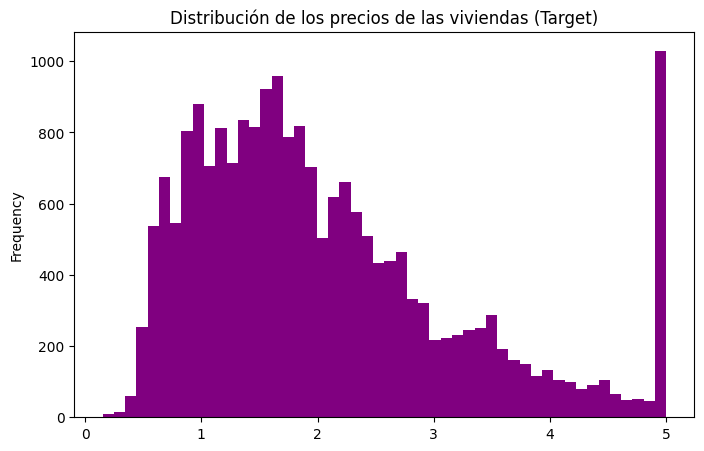

In [18]:
# 2.5 — Distribución de la variable objetivo
# Identificá cuál es la columna objetivo de tu dataset y graficá su distribución
# Pista: usá un gráfico de barras o torta. En la demo lo hicimos con matplotlib.

# ✏️ Primero: ¿cuál es el nombre de la columna objetivo en tu dataset?
columna_objetivo = 'NOMBRE_DE_LA_COLUMNA_OBJETIVO'

# ✏️ TU CÓDIGO ACÁ (gráfico de distribución)
columna_objetivo = 'target'
df[columna_objetivo].plot(
    kind='hist',
    bins=50,
    color='purple',
    figsize=(8, 5),
    title='Distribución de los precios de las viviendas (Target)'
)


array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>, <Axes: >]], dtype=object)

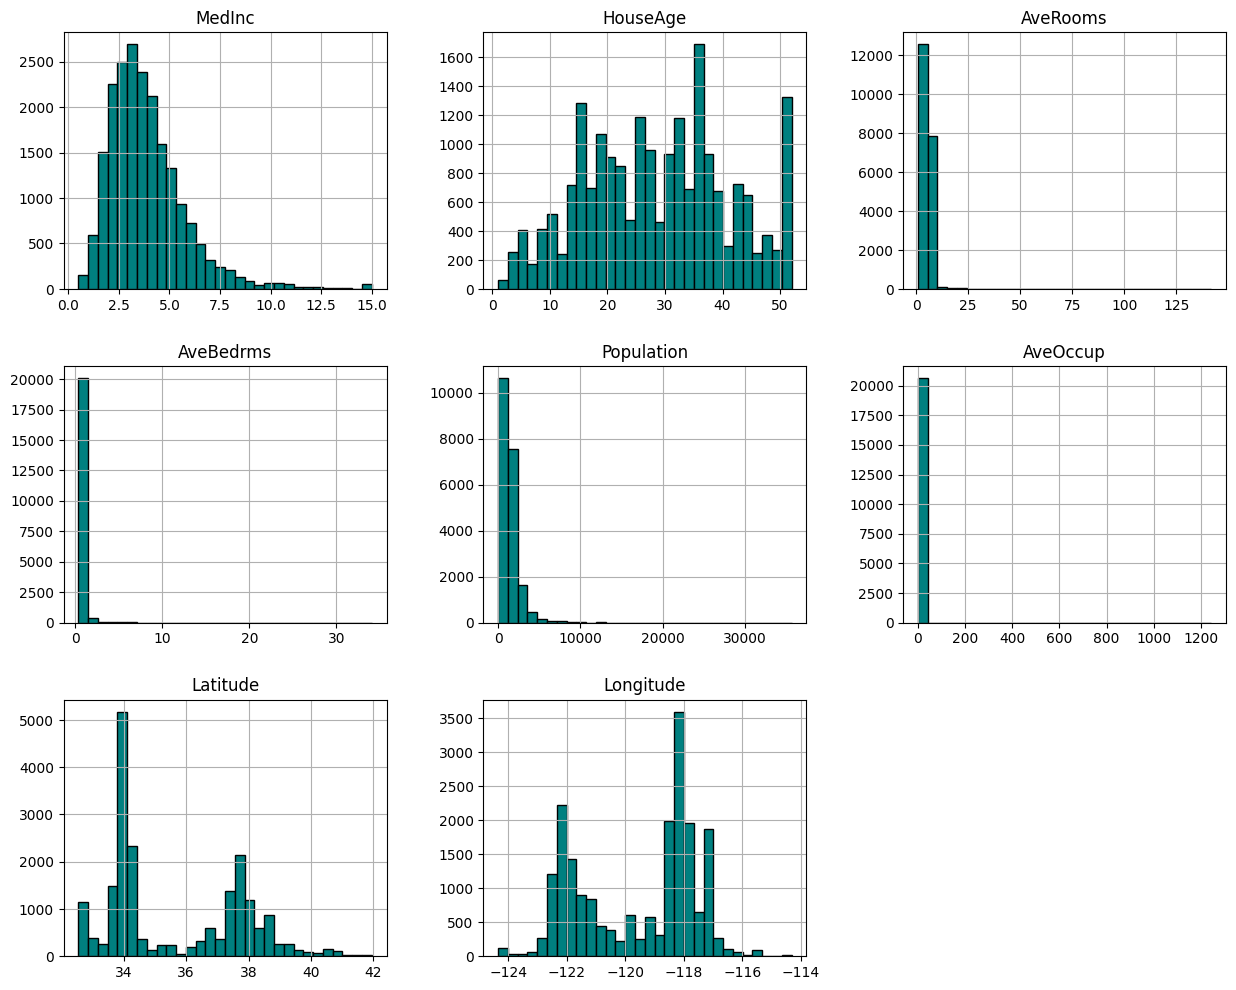

In [19]:
# 2.6 — Histogramas de variables numéricas
# Graficá la distribución de al menos 4 variables numéricas
# Pista: podés usar df.hist() para hacerlo más rápido, o hacer subplots como en la demo

df.drop(columns=['target']).hist(figsize=(15, 12), bins=30, color='teal', edgecolor='black')


In [20]:
# 2.7 — Mapa de correlaciones (Heatmap)
# Calculá la matriz de correlación e visualizala con seaborn
# Pista: usá df.corr() y sns.heatmap()
# Incluí la variable objetivo en el heatmap para ver qué variables se correlacionan con ella

df.corr().style.background_gradient(cmap='coolwarm').format(precision=2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
MedInc,1.00,-0.12,0.33,-0.06,0.00,0.02,-0.08,-0.02,0.69
HouseAge,-0.12,1.00,-0.15,-0.08,-0.30,0.01,0.01,-0.11,0.11
AveRooms,0.33,-0.15,1.00,0.85,-0.07,-0.00,0.11,-0.03,0.15
AveBedrms,-0.06,-0.08,0.85,1.00,-0.07,-0.01,0.07,0.01,-0.05
Population,0.00,-0.30,-0.07,-0.07,1.00,0.07,-0.11,0.10,-0.02
AveOccup,0.02,0.01,-0.00,-0.01,0.07,1.00,0.00,0.00,-0.02
Latitude,-0.08,0.01,0.11,0.07,-0.11,0.00,1.00,-0.92,-0.14
Longitude,-0.02,-0.11,-0.03,0.01,0.10,0.00,-0.92,1.00,-0.05
target,0.69,0.11,0.15,-0.05,-0.02,-0.02,-0.14,-0.05,1.00


### 💬 Reflexión 1 — EDA

*Hacé doble clic en esta celda para editar y responder las siguientes preguntas:*

**a)** ¿Tu dataset tiene valores faltantes? ¿En qué columnas y qué porcentaje representan?

*Tu respuesta:* No, es un dataset limpio que no contiene valores faltantes  en ninguna de sus columnas.

---

**b)** ¿Las clases de la variable objetivo están balanceadas? ¿Qué implicaría si no lo estuvieran para el modelo?

*Tu respuesta:*
El concepto de "clases balanceadas" no aplica porque el dataset asignado corresponde a un problema de regresión, no de clasificación. Nuestra variable objetivo es un valor numérico continuo

---

**c)** ¿Qué variable numérica tiene mayor correlación con la variable objetivo? ¿Tiene sentido desde el punto de vista del dominio del problema?

*Tu respuesta:*la variable con mayor correlación con el precio de la vivienda es "MedInc". Es lógico que en los barrios donde las personas tienen mayores ingresos económicos, el valor de las propiedades sea significativamente más alto.

---
## Sección 3 — Preprocesamiento

> Los algoritmos de ML solo entienden números y no toleran valores faltantes.
> En esta sección transformamos los datos para dejarlos listos para modelar.

In [21]:
# 3.1 — Crear una copia del DataFrame original
# SIEMPRE trabajar sobre una copia para no modificar los datos originales

# ✏️ TU CÓDIGO ACÁ
df_proc = df.copy()
print('✅ Copia creada')

✅ Copia creada


In [23]:
# 3.2 — Eliminar columnas irrelevantes o con demasiados faltantes
# Decisión: ¿hay alguna columna que no aporte información predictiva?
# (identificadores, nombres, columnas con >50% de faltantes)

# ✏️ TU CÓDIGO ACÁ (puede que no haya columnas para eliminar en tu dataset)
# columnas_a_eliminar = ['col1', 'col2']
# df_proc = df_proc.drop(columns=columnas_a_eliminar)


In [24]:
# 3.3 — Tratar valores faltantes
# Para variables numéricas: imputar con mediana o media
# Para variables categóricas: imputar con la moda
# Si no hay valores faltantes en tu dataset, documentalo con un print

print("Valores nulos en el dataset:", df_proc.isnull().sum().sum())


Valores nulos en el dataset: 0


In [25]:
# 3.4 — Codificar variables categóricas
# Si tu dataset tiene columnas de texto (dtype=object), hay que convertirlas a números
# Opciones: pd.get_dummies() para variables nominales, .map() para variables binarias
# Si tu dataset no tiene variables categóricas, documentalo con un print
print("No hay variables categóricas de texto en este dataset.")


No hay variables categóricas de texto en este dataset.


In [28]:
# 3.5 — Separar X (features) e y (variable objetivo)

# ✏️ Reemplazá 'NOMBRE_COLUMNA_OBJETIVO' con el nombre real en tu dataset
X = df_proc.drop(columns=['target'])
y = df_proc['target']

print(f'✅ X: {X.shape} | y: {y.shape}')
print(f'Features: {list(X.columns)}')

✅ X: (20640, 8) | y: (20640,)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [33]:
# 3.6 — Dividir en train y test (80% / 20%)


# Pista: usá train_test_split con test_size=0.2 y random_state=42
# Para clasificación, agregá stratify=y para mantener la proporción de clases
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [35]:
# 3.7 — Normalización con StandardScaler
# Recordá: fit solo en train, transform en ambos
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### 💬 Reflexión 2 — Preprocesamiento

*Hacé doble clic en esta celda para editar y responder:*

**a)** ¿Qué estrategia usaste para tratar los valores faltantes? ¿Por qué elegiste esa estrategia y no otra?

*Tu respuesta:* En nuestro caso, no fue necesario aplicar ninguna estrategia de imputación ya que o contiene valores faltantes en ninguna de sus columnas.

---

**b)** ¿Hubo variables categóricas en tu dataset? ¿Qué método de codificación usaste y por qué?

*Tu respuesta:* No. Todas las características ya están expresadas de forma nativa como valores numéricos continuos.

---

**c)** ¿Por qué es importante ajustar el StandardScaler solo con los datos de entrenamiento y no con todo el dataset?

*Tu respuesta:* Es importante para evitar la fuga de datos

---
## Sección 4 — Modelado

> Entrenamos al menos dos algoritmos y comparamos su desempeño.
> Recordá: siempre entrenar sobre **train** y evaluar sobre **test**.

In [41]:
# 4.1 — Importar algoritmos y métricas
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print('✅ Librerías de modelado importadas')

✅ Librerías de modelado importadas


In [46]:
# 4.2 — Entrenar el primer algoritmo
# Los árboles no necesitan datos escalados: usá X_train (no X_train_scaled)

promedio_precio = y_train.mean()
y_train_class = (y_train > promedio_precio).astype(int)
y_test_class = (y_test > promedio_precio).astype(int)
modelo1 = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo1.fit(X_train, y_train_class)
y_pred1 = modelo1.predict(X_test)
acc1_train = accuracy_score(y_train_class, modelo1.predict(X_train))
acc1_test  = accuracy_score(y_test_class, y_pred1)

print(f'Algoritmo 1 — Train: {acc1_train:.3f} | Test: {acc1_test:.3f}')


Algoritmo 1 — Train: 0.830 | Test: 0.823


In [47]:
# 4.3 — Entrenar el segundo algoritmo (diferente al primero)

modelo2 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
modelo2.fit(X_train, y_train_class)

y_pred2 = modelo2.predict(X_test)

acc2_train = accuracy_score(y_train_class, modelo2.predict(X_train))
acc2_test  = accuracy_score(y_test_class, y_pred2)

print(f'Algoritmo 2 (Random Forest) — Train: {acc2_train:.3f} | Test: {acc2_test:.3f}')


Algoritmo 2 (Random Forest) — Train: 0.918 | Test: 0.873


In [48]:
# 4.4 — Classification Report de ambos modelos
# Pista: classification_report(y_test, y_pred)

print("=== Reporte: Decision Tree ===")
print(classification_report(y_test_class, y_pred1, target_names=['Barata (0)', 'Cara (1)']))

print("\n=== Reporte: Random Forest ===")
print(classification_report(y_test_class, y_pred2, target_names=['Barata (0)', 'Cara (1)']))


=== Reporte: Decision Tree ===
              precision    recall  f1-score   support

  Barata (0)       0.81      0.93      0.86      2477
    Cara (1)       0.86      0.66      0.75      1651

    accuracy                           0.82      4128
   macro avg       0.83      0.80      0.81      4128
weighted avg       0.83      0.82      0.82      4128


=== Reporte: Random Forest ===
              precision    recall  f1-score   support

  Barata (0)       0.87      0.92      0.90      2477
    Cara (1)       0.87      0.80      0.83      1651

    accuracy                           0.87      4128
   macro avg       0.87      0.86      0.87      4128
weighted avg       0.87      0.87      0.87      4128



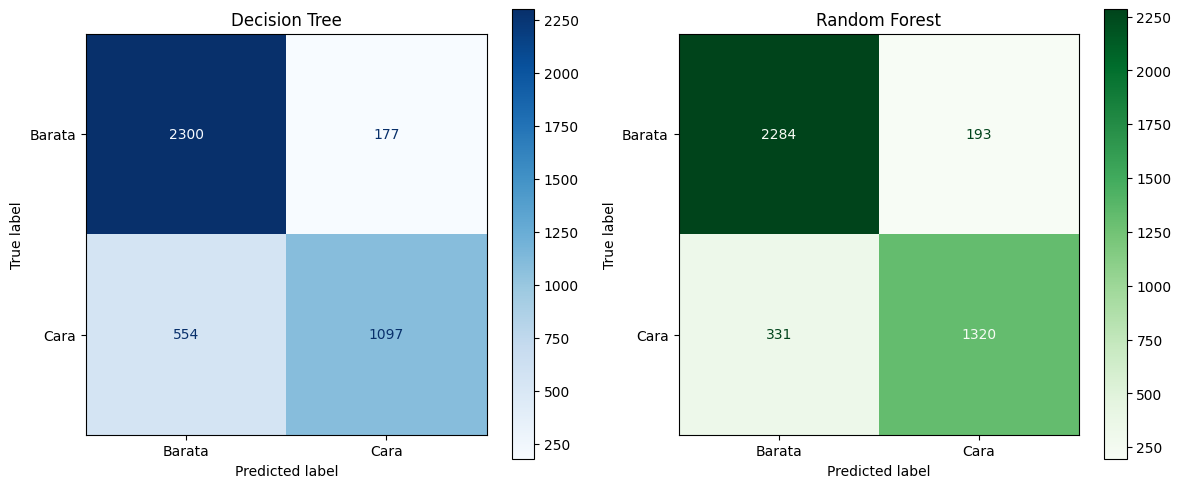

In [49]:
# 4.5 — Matrices de confusión (una por modelo, subplots 1x2)
# Pista: ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test_class, y_pred1, display_labels=["Barata", "Cara"], ax=ax[0], cmap='Blues')
ax[0].set_title('Decision Tree')

ConfusionMatrixDisplay.from_predictions(y_test_class, y_pred2, display_labels=["Barata", "Cara"], ax=ax[1], cmap='Greens')
ax[1].set_title('Random Forest')

plt.tight_layout()
plt.show()


<Axes: title={'center': 'Importancia de Variables (Random Forest)'}>

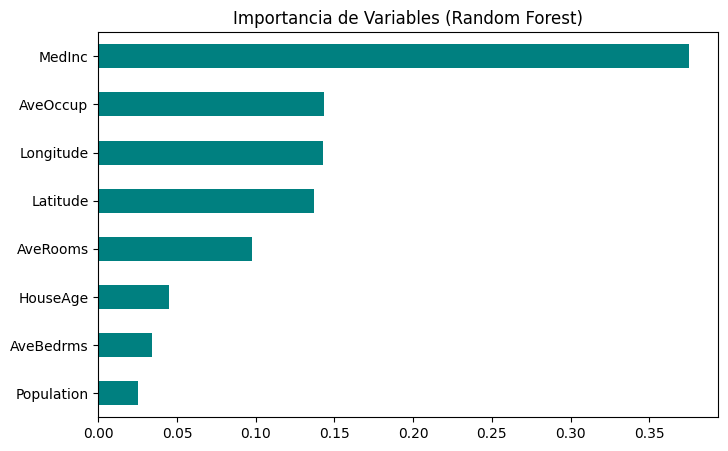

In [50]:
# 4.6 — Importancia de variables del mejor modelo
# Si usaste RandomForest: modelo.feature_importances_
# Graficá un barplot horizontal ordenado

importancias = pd.Series(modelo2.feature_importances_, index=X.columns)

importancias.sort_values().plot(
    kind='barh',
    figsize=(8, 5),
    color='teal',
    title='Importancia de Variables (Random Forest)'
)


### 💬 Reflexión 3 — Modelado y Evaluación

**a)** ¿Qué modelo tuvo mejor accuracy en test? ¿Detectaron sobreajuste en alguno?

*Tu respuesta:*
 El sobreajuste, el Árbol de Decisión generalizó con valores casi idénticos en Train (0.830) y Test (0.823). Por otro lado, el Random Forest sí muestra un ligero sobreajuste, ya que su rendimiento en Train fue casi perfecto (0.918) pero cayó un poco al enfrentarse a los datos de Test (0.873).

---

**b)** ¿Qué variables resultaron más importantes? ¿Tiene sentido desde el dominio del problema?

*Tu respuesta:*
Según el gráfico de importancia del Random Forest, la variable predominante y por mucha diferencia es MedInc, seguida por AveOccup, y la ubicación geográfica. el poder adquisitivo de los habitantes de un vecindario (MedInc) es el factor que más influye y determina el valor general de las propiedades en esa zona. Además, la densidad poblacional o tamaño de las familias (AveOccup) y la ubicación exacta (las coordenadas) son reglas históricas en el rubro inmobiliario para definir si un distrito es considerado premium o accesible.
---

**c)** ¿Qué decisión empresarial podría informar este modelo?

*Tu respuesta:*
Una empresa inmobiliaria podría utilizar este modelo para automatizar las tasaciones iniciales. Al ingresar las características de una nueva propiedad y su barrio, el algoritmo predice con un 87% de exactitud si la casa pertenece a la categoría de valor "alto" o "bajo".

---
## Sección 5 — Verificación final

Antes de entregar, ejecutá esta celda para confirmar que el preprocesamiento está completo.

In [51]:
# Verificación automática del preprocesamiento
print('=== VERIFICACIÓN FINAL ===')

try:
    print(f'✅ X_train: {X_train.shape} | X_test: {X_test.shape}')
    print(f'✅ y_train: {y_train.shape} | y_test: {y_test.shape}')
    print(f'✅ Valores faltantes en X_train: {pd.DataFrame(X_train).isnull().sum().sum()}')
    print(f'✅ Valores faltantes en X_test:  {pd.DataFrame(X_test).isnull().sum().sum()}')
    print(f'✅ X_train_scaled: {X_train_scaled.shape}')
    print('\n🎉 ¡Preprocesamiento completo! Listos para modelar en la próxima clase.')
except NameError as e:
    print(f'❌ Variable no definida: {e}')
    print('   Revisá que completaste todas las celdas anteriores.')

=== VERIFICACIÓN FINAL ===
✅ X_train: (16512, 8) | X_test: (4128, 8)
✅ y_train: (16512,) | y_test: (4128,)
✅ Valores faltantes en X_train: 0
✅ Valores faltantes en X_test:  0
✅ X_train_scaled: (16512, 8)

🎉 ¡Preprocesamiento completo! Listos para modelar en la próxima clase.
